<a href="https://colab.research.google.com/github/MSGamgee85/MSGamgee85/blob/main/EGF_11_Lista_Exercicios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Google Colab](https://img.shields.io/badge/Google%20Colab-F9AB00?logo=googlecolab&logoColor=fff)](#) 	[![Python](https://img.shields.io/badge/Python-3776AB?logo=python&logoColor=fff)](#) [![GitHub](https://img.shields.io/badge/GitHub-%23121011.svg?logo=github&logoColor=white)](#)

---
<h4>
<h3><center><b> MBA Gestão Financeira - EPUSP <br>
EGF-11 Gestão de Riscos <br>
Lista de Exercícios – 2026 </b></center><br>

---

<center><small><i> Alexandre Galetti </i></small></center>

### **Gestão de Risco de Crédito**

---

<u>Risco de crédito</u> é o risco de que ocorra **calote** do tomador de recursos, de tal forma que os juros e o principal não serão pagos ao credor. Instituições financeiras buscam mitigar esse risco através do provisionamento de recursos para cobrir as perdas.

Com base nos conceitos de gestão de risco de crédito apresentados nas aulas EGF-11 e no livro-texto de Hull (vide referências), o provisionamento e o capital econômico são calculados utilizando-se as <u>métricas</u> de **Perda Esperada (EL)** e **Perda Não Esperada (UL)**, respectivamente.

<center><b>Figura 1 -</b> Distribuição probabilística de perdas </center>

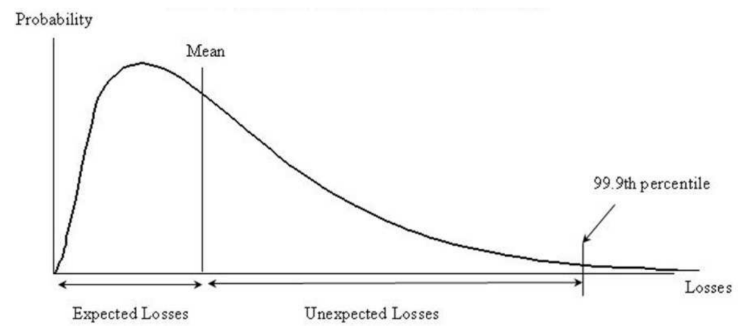

<small><b>Fonte:</b> JURCA, P. Faculty of Mathematics, Physics and Informatics. Comenius University of Bratislava. Disponível em <https://fmph.uniba.sk/en/departments/department-of-applied-mathematics-and-statistics/> Acesso em: 02 mai. 2026 </small>

<br>

1. **Provisionamento (Perda Esperada - EL)**
O provisionamento é o valor reservado para cobrir a Perda Esperada, que representa o <u>custo médio</u> previsível de uma <u>operação de crédito</u>

2. **Capital Econômico (Perda Não Esperada - UL)**
O capital econômico é o montante de capital próprio destinado a absorver perdas que excedem a média, conhecidas como Perdas Não Esperadas (UL). Estas representam a <u>volatilidade do risco</u>.

<br>

Em resumo, o provisionamento é calculado sobre a <u>média das perdas previstas (EL)</u>, enquanto o capital econômico é dimensionado para suportar a <u>variabilidade dessas perdas (UL)</u>, garantindo a **solvência** da instituição em cenários adversos.

---
<small> Nota:
* EL = do inglês "Expected Loss"
* UL = do inglês Unexpected Loss" </small>

In [ ]:
# Bibliotecas utilizadas
import numpy as np                # funções matemáticas e operações com vetores e matrizes
import matplotlib.pyplot as plt   # geração e visualização de gráficos
import warnings                   # avisos e alertas
warnings.filterwarnings('ignore') # ignora avisos e alertas
from scipy.stats import norm      # distribuição normal da biblioteca scipy
from scipy.optimize import fsolve # encontra raízes de equações não-lineares do tipo f(x) = 0 a partir de uma estimativa

### **Exercício 1: Portfólio de 2 Ativos Descorrelacionados**

---

<u>Conceitos e Fórmulas</u>:
1. **Perda Esperada (EL)**: É a média da distribuição de perdas. Representa o valor que a instituição espera perder, em média, em suas operações de crédito:

&emsp;&emsp; $\boxed{EL=EAD⋅PD⋅LGD}$ <br>

onde:

* $EAD =$ `exposure at default` = exposição ao calote = valor do crédito/empréstimo concedido ao tomador
* $PD =$ `probability of default` = probabilidade do calote
* $LGD =$ `loss given default` = perda devido ao calote = estimativa da porcentagem do crédito/empréstimo que será perdida no caso de calote
* $RR =$ `recovery rate` = taxa de recuperação = porcentagem do crédito/empréstimo que será recuperada: $\boxed{RR = 1 - LGD}$

&emsp;&emsp; A perda esperada para o portfólio é dada por:

&emsp;&emsp; $\boxed{EL_{PF}
 =\displaystyle \sum_{i=1}^n
EL_i}$

2. **Perda Não Esperada (UL)**: Representa a variabilidade (desvio padrão = volatilidade) da perda em torno da média

&emsp;&emsp; Para um ativo:

&emsp;&emsp; $\boxed{UL=EAD \cdot \sqrt{PD \cdot σ^2_{LGD}+LGD^2 \cdot PD(1−PD)}}$

&emsp;&emsp; Para ativos descorrelacionados ($ρ=0$): <br>

&emsp;&emsp; $\boxed{UL_{PF} = \sqrt{\displaystyle \sum_{i=1}^n UL^2_i}}$

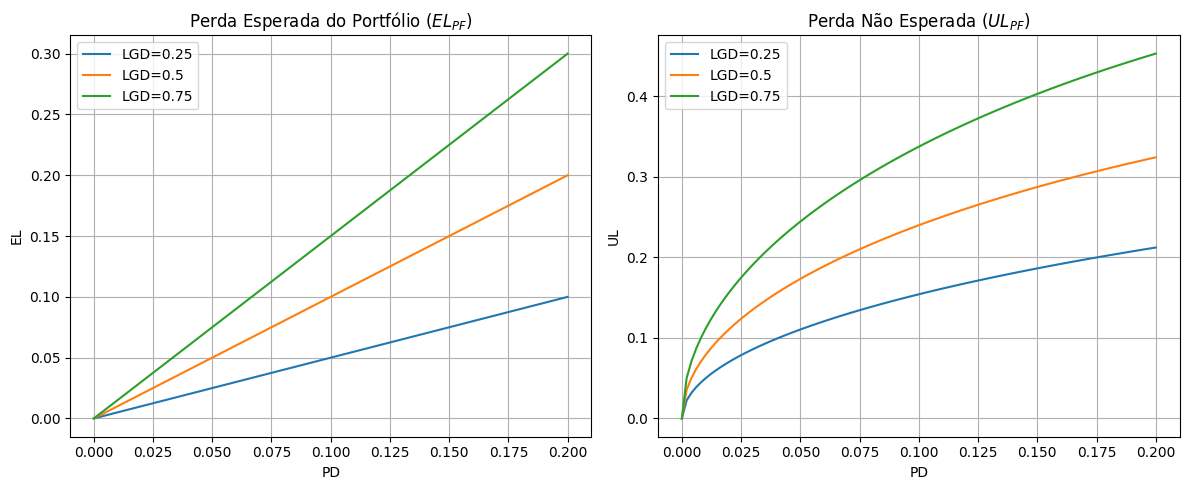

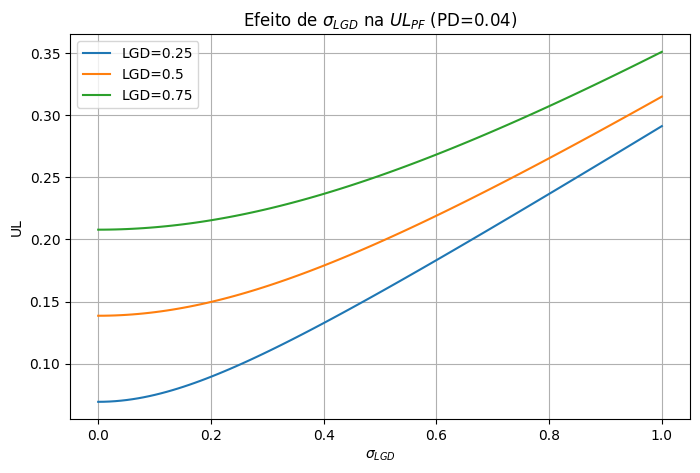

In [ ]:
# ------------#
# Exercício 1 #
# ------------#

# Parâmetros
ead = 1
sigma_lgd = 0.25
pd_range = np.linspace(0, 0.2, 100)
lgd_values = [0.25, 0.5, 0.75]

# Funções
def calc_el(ead, pd, lgd):
    return ead * pd * lgd

def calc_ul(ead, pd, lgd, sigma_lgd):
    return ead * np.sqrt(pd * sigma_lgd**2 + lgd**2 * pd * (1 - pd))

# a & c. Perda Esperada e Não Esperada
plt.figure(figsize=(12, 5))

# Gráfico EL
plt.subplot(1, 2, 1)
for lgd in lgd_values:
    el_pf = 2 * calc_el(ead, pd_range, lgd) # 2 ativos
    plt.plot(pd_range, el_pf, label=f'LGD={lgd}')
plt.title('Perda Esperada do Portfólio ($EL_{PF}$)')
plt.xlabel('PD')
plt.ylabel('EL')
plt.legend()
plt.grid(True)

# Gráfico UL
plt.subplot(1, 2, 2)
for lgd in lgd_values:
    ul_i = calc_ul(ead, pd_range, lgd, sigma_lgd)
    ul_pf = np.sqrt(2 * ul_i**2) # descorrelacionados
    plt.plot(pd_range, ul_pf, label=f'LGD={lgd}')
plt.title('Perda Não Esperada ($UL_{PF}$)')
plt.xlabel('PD')
plt.ylabel('UL')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# e. Efeito de sigma_LGD na UL
pd_fixo = 0.04
sigma_lgd_range = np.linspace(0, 1, 100)

plt.figure(figsize=(8, 5))
for lgd in lgd_values:
    ul_i = calc_ul(ead, pd_fixo, lgd, sigma_lgd_range)
    ul_pf = np.sqrt(2 * ul_i**2)
    plt.plot(sigma_lgd_range, ul_pf, label=f'LGD={lgd}')
plt.title(f'Efeito de $\sigma_{{LGD}}$ na $UL_{{PF}}$ (PD={pd_fixo})')
plt.xlabel('$\sigma_{LGD}$')
plt.ylabel('UL')
plt.legend()
plt.grid(True)
plt.show()

**Análise dos Resultados (Itens b, d, f):**

---

* $EL$ (**Item b**): O gráfico da $EL$ é linear em relação à $PD$ e à $LGD$. Como os ativos são idênticos, a perda dobra em relação ao ativo individual. O aumento da severidade ($LGD$) inclina a reta da perda esperada

* $UL$ (**Item d**): A $UL$ cresce de forma côncava (formato de raiz quadrada) com a $PD$
. Isso ocorre porque a incerteza do default aumenta rapidamente no início, mas o termo $PD(1−PD)$ atinge um pico (em $0.5$, fora do intervalo $[0, 0.2]$).

* $σ_{LGD}$ (**Item f**): Conforme $σ_{LGD}$
aumenta, a incerteza sobre quanto será recuperado em caso de default cresce, elevando diretamente a $UL$. O efeito é mais pronunciado para $LGD$s menores em termos proporcionais, mas a $UL$ total é sempre maior para $LGD$s elevados.

### **Exercício 2: Portfólio Correlacionado**

---

<u>Conceitos e Fórmulas</u>:

1. **UL com Correlação (ρ)**: Quando os ativos são correlacionados, o risco do portfólio depende de como os defaults ocorrem simultaneamente:

&emsp; &emsp; $\boxed{UL_{PF}=\sqrt{(UL_1)^2+(UL_2)^2+2⋅ρ_{1,2}⋅UL_1 ⋅ UL_2}}$

Neste caso, a $LGD$ é determinística, logo $σ
_{LGD}=0$


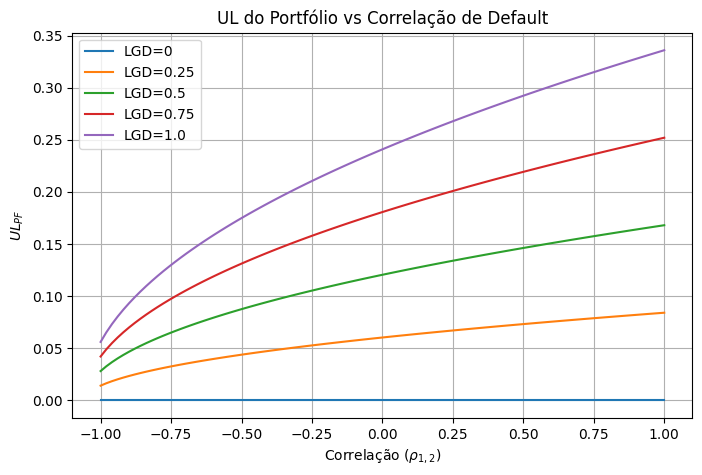

In [ ]:
#-------------#
# Exercício 2 #
#-------------#

# Parâmetros
pd1, pd2 = 0.02, 0.04
lgds = [0, 0.25, 0.5, 0.75, 1.0]
rho = np.linspace(-1, 1, 100)

def calc_ul_det(ead, pd, lgd):
    return ead * lgd * np.sqrt(pd * (1 - pd))

ul1_vals = [calc_ul_det(1, pd1, l) for l in lgds]
ul2_vals = [calc_ul_det(1, pd2, l) for l in lgds]

plt.figure(figsize=(8, 5))
for i, lgd in enumerate(lgds):
    ul_pf = np.sqrt(ul1_vals[i]**2 + ul2_vals[i]**2 + 2 * rho * ul1_vals[i] * ul2_vals[i])
    plt.plot(rho, ul_pf, label=f'LGD={lgd}')

plt.title('UL do Portfólio vs Correlação de Default')
plt.xlabel('Correlação ($\\rho_{1,2}$)')
plt.ylabel('$UL_{PF}$')
plt.legend()
plt.grid(True)
plt.show()

**Análise dos Resultados (Itens b, c, d, e):**

---

* <b>Efeito da LGD (Item b)</b>: A $UL$ escala linearmente com a $LGD$ quando esta é determinística
. Se $LGD=0$, o risco é zero; se $LGD=1$, o risco é máximo.
* <b>Diversificação (Item c)</b>: A diversificação é maximizada quando a correlação é mínima ($ρ=−1$)
. O risco é minimizado em situações de correlação negativa, pois o default de um ativo tende a ser compensado pela sobrevivência do outro.
* <b>Correlação Perfeita (Item d)</b>: Para $ρ=1$, as perdas são perfeitamente aditivas ($UL_{PF}=UL_1+UL_2$), eliminando o benefício da diversificação
.
* <b>Correlação Negativa (Item e)</b>: Mesmo com $ρ=−1$, a $UL
_{PF}>0$ porque as $UL$s individuais são diferentes ($PD_1 \neq PD_2$)
. Para o risco ser zero com $ρ=−1$, as posições teriam que ser idênticas para se anularem perfeitamente.

### **Exercício 3: Modelo de Merton**

---

<u>Conceitos e Fórmulas</u>:

1. O modelo de Merton trata o patrimônio líquido ($E_t$) como uma **opção de compra** sobre os ativos da empresa ($A_t$) no instante t:

&emsp;&emsp; $\boxed{E_t=A_t N(d_1)−Le^{−rT}N(d_2)}$

&emsp;&emsp; onde:

- $L=$ montante de juros e principal da dívida a ser paga no tempo T

- $d_1 = \dfrac{ln(A_t/L)+(r+\sigma^2_A/2)T}{\sigma_A \sqrt{T}}$

- $d_2 = d_1 - \sigma_A \sqrt{T}$

- $σ_E =σ_A N(d_1)\frac{A_t}{E_t}$ = volatilidade instantânea do patrimônio líquido (<i>equity</i>)<br>

- $\sigma_A =$ volatilidade dos ativos (suposta constante)

2. <b>Distância ao Default</b> ($DD$): Mede quantos desvios padrões o valor da empresa está do ponto de insolvência:

&emsp; &emsp; $\boxed{DD=\dfrac{ln(A_t)+(r -\frac{\sigma^2_A}{2})T-ln(L)}{\sigma_A \sqrt{T}}}$

&emsp; &emsp; A DD pode ser interpretada como o resultado (valor de saída) do modelo de Merton. Quanto menor o valor de DD, mais provável o risco de calote da empresa.

3. <b>Probabilidade de Defaut ($PD$):</b> é calculada a partir da distribuição normal da distância ao default:

&emsp; &emsp; $\boxed{PD=N(−DD)}$

&emsp; &emsp; onde:

- $N(\cdot)=$ distribuição de probabilidade normal


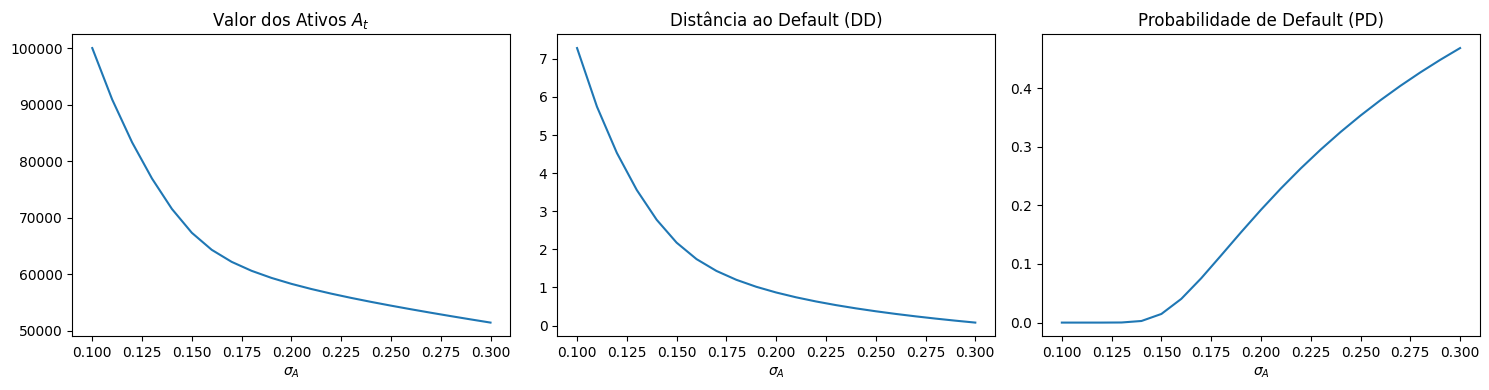

PD para sigma_E=0.4 (sigma_A=0.3): 46.8411%
PD para sigma_E=0.3 (sigma_A=0.3): 58.7366%
PD para sigma_E=0.2 (sigma_A=0.3): 71.5699%


In [ ]:
#-------------#
# Exercício 3 #
#-------------#

# Parâmetros
Et = 25000
L = 50000
r = 0.04
T = 1
sigma_e_fixo = 0.4
sigma_a_range = np.arange(0.1, 0.31, 0.01)

def merton_equations(vars_input, Et, sigma_e, L, r, T, sigma_a_val):
    At = float(vars_input[0])
    d1 = (np.log(At / L) + (r + 0.5 * sigma_a_val**2) * T) / (sigma_a_val * np.sqrt(T))
    d2 = d1 - sigma_a_val * np.sqrt(T)

    eq = sigma_a_val * norm.cdf(d1) * At / Et - sigma_e
    return [eq]

at_results = []
for sa in sigma_a_range:
    # Estimativa inicial: At = Et + L
    sol = fsolve(merton_equations, [Et + L], args=(Et, sigma_e_fixo, L, r, T, sa))
    at_results.append(sol[0])

# b & c. DD e PD
at_results = np.array(at_results)
d1 = (np.log(at_results / L) + (r + 0.5 * sigma_a_range**2) * T) / (sigma_a_range * np.sqrt(T))
dd = (np.log(at_results) + (r - 0.5 * sigma_a_range**2) * T - np.log(L)) / (sigma_a_range * np.sqrt(T))
pd = norm.cdf(-dd)

# Plotagem Merton
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1); plt.plot(sigma_a_range, at_results); plt.title('Valor dos Ativos $A_t$'); plt.xlabel('$\sigma_A$')
plt.subplot(1, 3, 2); plt.plot(sigma_a_range, dd); plt.title('Distância ao Default (DD)'); plt.xlabel('$\sigma_A$')
plt.subplot(1, 3, 3); plt.plot(sigma_a_range, pd); plt.title('Probabilidade de Default (PD)'); plt.xlabel('$\sigma_A$')
plt.tight_layout(); plt.show()

# e. Comparação sigma_E
def get_pd_merton(sigma_e_val, sigma_a_target):
    sol = fsolve(merton_equations, [Et + L], args=(Et, sigma_e_val, L, r, T, sigma_a_target))
    At_val = sol[0] # Extrai o valor escalar da solução
    dd_val = (np.log(At_val) + (r - 0.5 * sigma_a_target**2) * T - np.log(L)) / (sigma_a_target * np.sqrt(T))
    return norm.cdf(-dd_val)

print(f"PD para sigma_E=0.4 (sigma_A=0.3): {get_pd_merton(0.4, 0.3):.4%}")
print(f"PD para sigma_E=0.3 (sigma_A=0.3): {get_pd_merton(0.3, 0.3):.4%}")
print(f"PD para sigma_E=0.2 (sigma_A=0.3): {get_pd_merton(0.2, 0.3):.4%}")

**Análise (Item d, e):**

---

* <b>Estrutura de Endividamento (Item d)</b>: À medida que a volatilidade dos ativos ($σ
_A$) aumenta, para manter uma volatilidade do equity ($σ_E$
​) constante, o valor implícito dos ativos ($A_t$) tende a ser menor ou a estrutura de capital torna-se mais arriscada
. Isso reduz a $DD$ e aumenta a $PD$.
* <b> Variação de </b> $σ_E$ <b> (Item e) </b>: Ao reduzir $σ_E$ de $0.4$ para $0.2$ (mantendo $σ_A=0.3$), a $PD$ diminui significativamente. Isso ocorre porque uma menor volatilidade do equity, dado um mesmo risco operacional ($σ_A$), implica que o valor de mercado dos ativos está muito mais acima do nível da dívida ($L$), aumentando a margem de segurança e a distância ao default.

### **Referências**

---

HULL, J. **<i>Risk Management and Financial Institutions**</i>. John Wiley & Sons, 2023.

OLIVEIRA, A. **Gestão de Riscos - Notas de Aula**. MBA em Engenharia Financeira. Escola Politécnica da USP. São Paulo, 2026.